In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

In [20]:

all_tip_to_com_dists=[]
for i in range(len(systems)):
    sub=[]
    for j in range(len(systems[i])):
        tu = systems[i][j]
        tipres = tu.select_atoms("name CA and resid 334")
        protein = tu.select_atoms("protein and not resid 324:345")
        
        tip_to_com_dists=[]
        for t in range(len(tu.trajectory)):
            tu.trajectory[t]
            tip_to_com=tipres.atoms.positions[0] - protein.center_of_geometry()
            tip_to_com_dist = sqrt(dot(tip_to_com,tip_to_com))
            tip_to_com_dists.append(tip_to_com_dist)
            
        sub.append(tip_to_com_dists)
    all_tip_to_com_dists.append(sub)


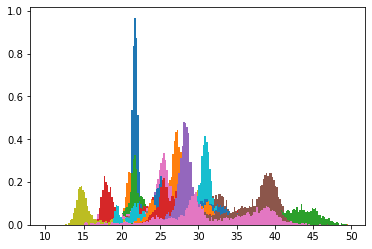

In [21]:
binrange = arange(10,50,0.2)

all_tip_to_com_dists_hists=[]

for i in range(len(all_tip_to_com_dists)):
    sub=[]
    for j in range(len(all_tip_to_com_dists[i])):
        a=hist(all_tip_to_com_dists[i][j],bins = binrange,density = True)
        sub.append(a[0])
    all_tip_to_com_dists_hists.append(sub)

In [22]:
figure(figsize = (16,12))
avg_all_tip_to_com_dists_hists=[]
sem_all_tip_to_com_dists_hists=[]
for i in range(len(all_tip_to_com_dists_hists)):
    avg_all_tip_to_com_dists_hists.append(mean(all_tip_to_com_dists_hists[i],axis = 0))
    sem_all_tip_to_com_dists_hists.append(scipy.stats.sem(all_tip_to_com_dists_hists[i],axis = 0))
    


<Figure size 1152x864 with 0 Axes>

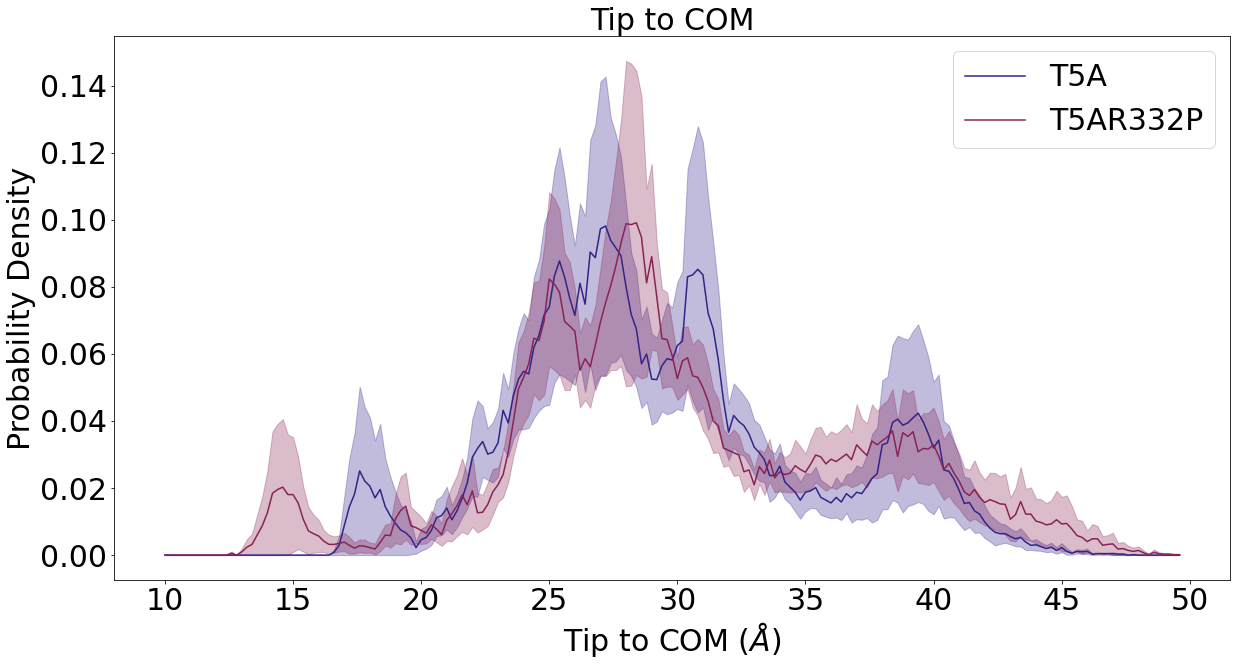

In [23]:


figure(figsize = (20,10))
#plot(binrange[:-1],avg_all_tip_to_com_dists_hists[0],color = colourScheme[0],label = system_names[0])
plot(binrange[:-1],avg_all_tip_to_com_dists_hists[1],color = colourScheme[1],label = system_names[1])
plot(binrange[:-1],avg_all_tip_to_com_dists_hists[2],color = colourScheme[2],label = system_names[2])


#fill_between(binrange[:-1], avg_all_tip_to_com_dists_hists[0] - sem_all_tip_to_com_dists_hists[0],avg_all_tip_to_com_dists_hists[0] + sem_all_tip_to_com_dists_hists[0],color = colourScheme[0],alpha = 0.3)
fill_between(binrange[:-1], avg_all_tip_to_com_dists_hists[1] - sem_all_tip_to_com_dists_hists[1],avg_all_tip_to_com_dists_hists[1] + sem_all_tip_to_com_dists_hists[1],color = colourScheme[1],alpha = 0.3)
fill_between(binrange[:-1], avg_all_tip_to_com_dists_hists[2] - sem_all_tip_to_com_dists_hists[2],avg_all_tip_to_com_dists_hists[2] + sem_all_tip_to_com_dists_hists[2],color = colourScheme[2],alpha = 0.3)


xlabel("Tip to COM ($\AA$)",fontsize = 30)
ylabel("Probability Density",fontsize = 30)
title("Tip to COM",fontsize = 30)
xticks(fontsize = 30)
yticks(fontsize = 30)

legend(fontsize = 30)

NameError: name 'binrange' is not defined